# WiFi消費電流測定 v3 (READY待ち方式、Beacon版)

READY受信待ち方式でのWiFiスキャン消費電流を測定。2個体で比較。

- **個体1**: current_log_wifi_v3_beacon_1.csv
- **個体2**: current_log_wifi_v3_beacon_2.csv

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Meiryo'
plt.rcParams['axes.unicode_minus'] = False

FILES = {
    '個体1': 'dist/current_log_wifi_v3_beacon_1.csv',
    '個体2': 'dist/current_log_wifi_v3_beacon_2_retry.csv',
}

SCAN_PATTERNS_MS = [3000, 5000, 10000]
REPS_PER_PATTERN = 5

In [8]:
# ============================================================
# データ読み込み + 解析
# ============================================================
results_all = {}

for label, csv_file in FILES.items():
    df = pd.read_csv(csv_file)
    df['Timestamp'] = pd.to_datetime(df['Timestamp'])
    valid_idx = df[df['Current (mA)'] > -10].index[0]
    df = df.iloc[valid_idx:].reset_index(drop=True)
    df['elapsed_s'] = (df['Timestamp'] - df['Timestamp'].iloc[0]).dt.total_seconds()
    
    current = df['Current (mA)'].values
    timestamps = df['elapsed_s'].values
    dt = np.median(np.diff(timestamps))
    
    # ON区間検出
    is_on = current > 30
    transitions = np.diff(is_on.astype(int))
    on_starts = np.where(transitions == 1)[0] + 1
    on_ends = np.where(transitions == -1)[0] + 1
    if is_on[0]: on_starts = np.insert(on_starts, 0, 0)
    if is_on[-1]: on_ends = np.append(on_ends, len(is_on))
    n = min(len(on_starts), len(on_ends))
    
    valid = []
    for i in range(n):
        s, e = on_starts[i], on_ends[i]
        dur = timestamps[min(e, len(timestamps)-1)] - timestamps[s]
        if dur >= 1.0: valid.append((s, e))
    
    # ベースライン (WiFi区間のOFF部分)
    wifi_on_idx = set()
    for s, e in valid[:15]: wifi_on_idx.update(range(s, e))
    wifi_start = timestamps[valid[0][0]]
    wifi_end = timestamps[valid[min(14, len(valid)-1)][1]]
    wifi_range = (timestamps >= wifi_start) & (timestamps <= wifi_end)
    wifi_off = df[wifi_range & ~df.index.isin(wifi_on_idx)]
    baseline = wifi_off['Current (mA)'].mean()
    
    # パターン別集計
    wifi_results = []
    for i, (s, e) in enumerate(valid[:15]):
        seg = current[s:e]
        dur = timestamps[min(e, len(timestamps)-1)] - timestamps[s]
        pidx = i // REPS_PER_PATTERN
        charge = seg.sum() * dt
        wifi_results.append({
            'scan_ms': SCAN_PATTERNS_MS[pidx],
            'rep': i % REPS_PER_PATTERN + 1,
            'duration_s': dur,
            'mean_mA': seg.mean() - baseline,
            'peak_mA': seg.max() - baseline,
            'charge_mAs': charge,
        })
    
    df_wifi = pd.DataFrame(wifi_results)
    summary = df_wifi.groupby('scan_ms').agg(
        回数=('mean_mA', 'count'),
        ON区間秒=('duration_s', 'mean'),
        平均電流=('mean_mA', 'mean'),
        標準偏差=('mean_mA', 'std'),
        ピーク=('peak_mA', 'max'),
        平均charge=('charge_mAs', 'mean'),
    ).reset_index()
    
    results_all[label] = {'summary': summary, 'baseline': baseline, 'df': df, 'valid': valid}
    
    print(f'\n=== {label} (baseline={baseline:.2f}mA) ===')
    print(summary.to_string(index=False))


=== 個体1 (baseline=0.42mA) ===
 scan_ms  回数     ON区間秒       平均電流     標準偏差        ピーク    平均charge
    3000   5  5.220361 119.506114 1.024480 277.575181  626.230359
    5000   5  7.195530 131.241223 0.970228 279.475181  944.362659
   10000   5 12.694942 141.257991 0.991843 266.775181 1794.835007

=== 個体2 (baseline=-0.05mA) ===
 scan_ms  回数     ON区間秒       平均電流     標準偏差        ピーク    平均charge
    3000   5  4.997184 152.305154 2.992209 328.447451  749.973728
    5000   5  7.241122 159.475244 2.717332 343.047451 1145.240025
   10000   5 12.491766 164.147023 1.638092 343.747451 2035.722376


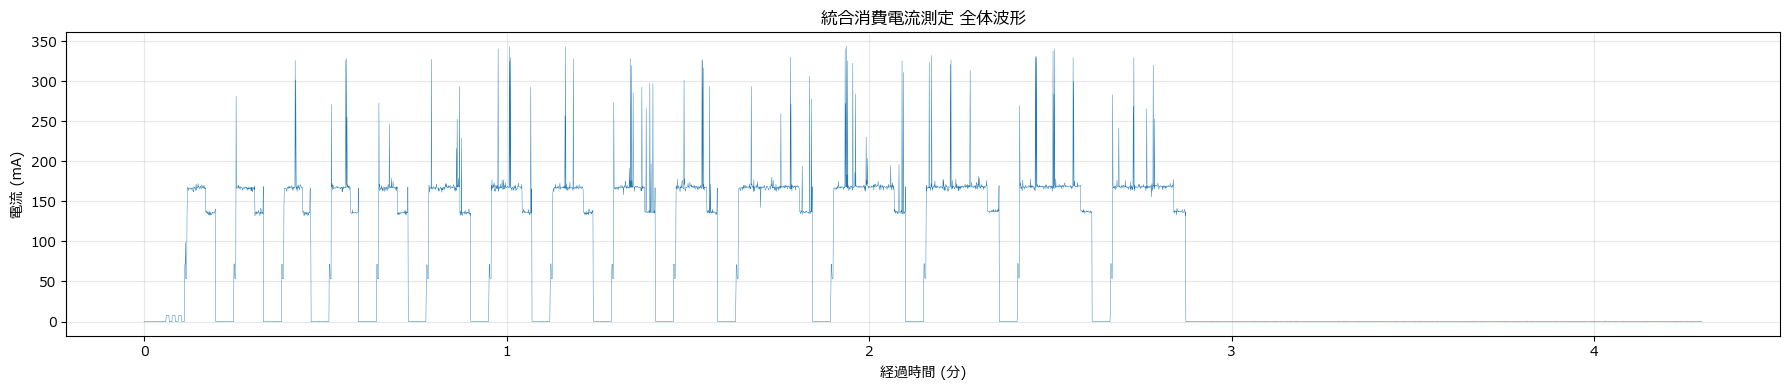

In [9]:
# ============================================================
# 全体の電流波形
# ============================================================
fig, ax = plt.subplots(figsize=(18, 4))
ax.plot(df['elapsed_s']/60, df['Current (mA)'], linewidth=0.3)
ax.set_xlabel('経過時間 (分)')
ax.set_ylabel('電流 (mA)')
ax.set_title('統合消費電流測定 全体波形')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

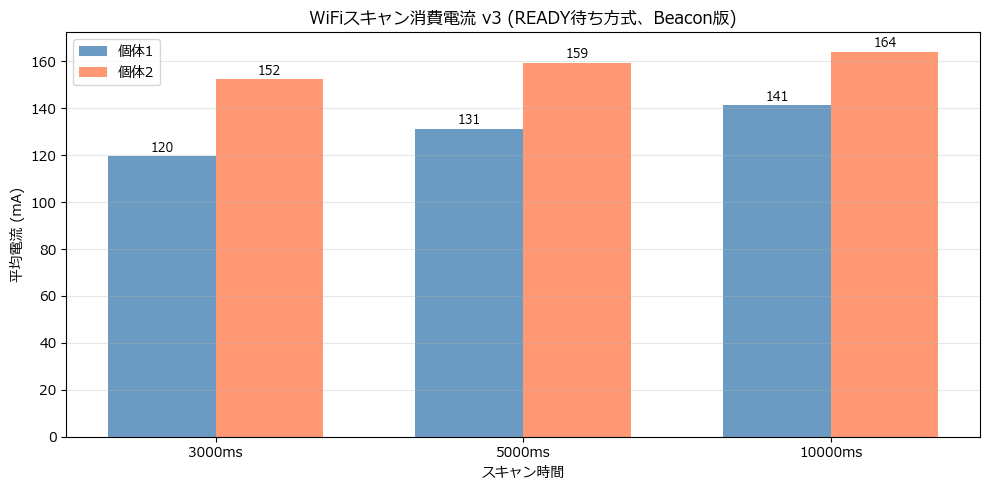

In [10]:
# ============================================================
# 比較グラフ
# ============================================================
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(SCAN_PATTERNS_MS))
width = 0.35
colors = ['steelblue', 'coral']

for i, (label, data) in enumerate(results_all.items()):
    s = data['summary']
    vals = s['平均電流'].values
    ax.bar(x + i * width, vals, width, label=label, color=colors[i], alpha=0.8)
    for j, v in enumerate(vals):
        ax.text(x[j] + i * width, v + 2, f'{v:.0f}', ha='center', fontsize=9)

ax.set_xlabel('スキャン時間')
ax.set_ylabel('平均電流 (mA)')
ax.set_title('WiFiスキャン消費電流 v3 (READY待ち方式、Beacon版)')
ax.set_xticks(x + width / 2)
ax.set_xticklabels([f'{ms}ms' for ms in SCAN_PATTERNS_MS])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

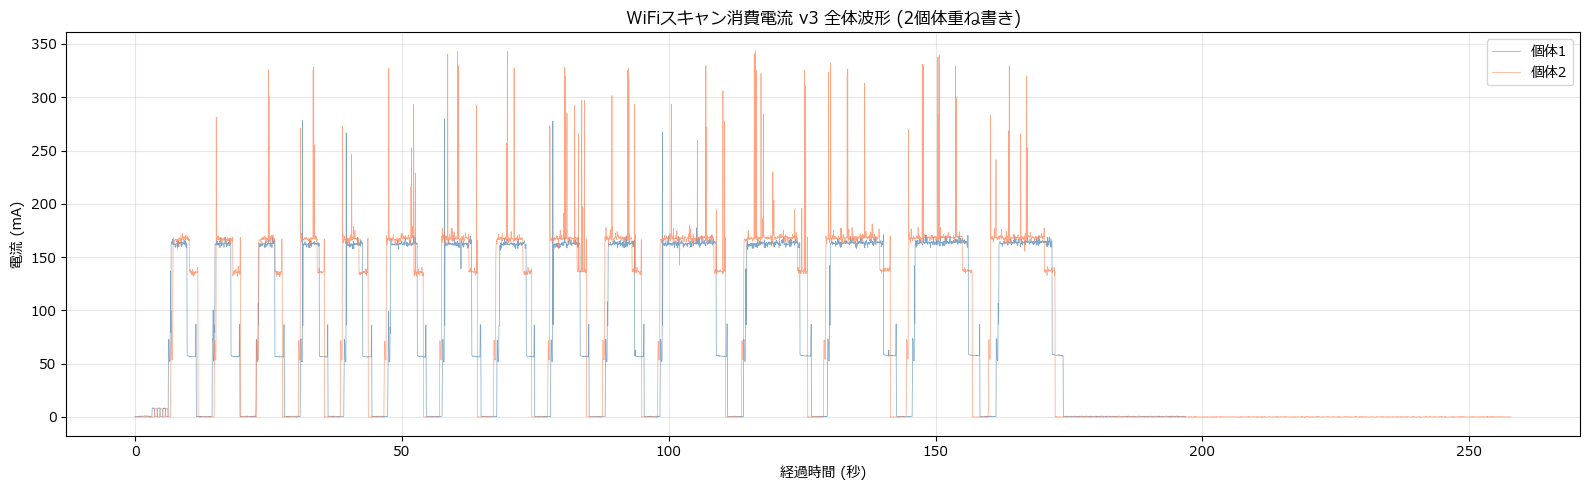

In [11]:
# ============================================================
# 全体の電流波形 (2個体重ね書き)
# ============================================================
fig, ax = plt.subplots(figsize=(16, 5))

colors = ['steelblue', 'coral']
for i, (label, data) in enumerate(results_all.items()):
    df_plot = data['df']
    ax.plot(df_plot['elapsed_s'], df_plot['Current (mA)'],
            linewidth=0.5, color=colors[i], alpha=0.7, label=label)

ax.set_xlabel('経過時間 (秒)')
ax.set_ylabel('電流 (mA)')
ax.set_title('WiFiスキャン消費電流 v3 全体波形 (2個体重ね書き)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

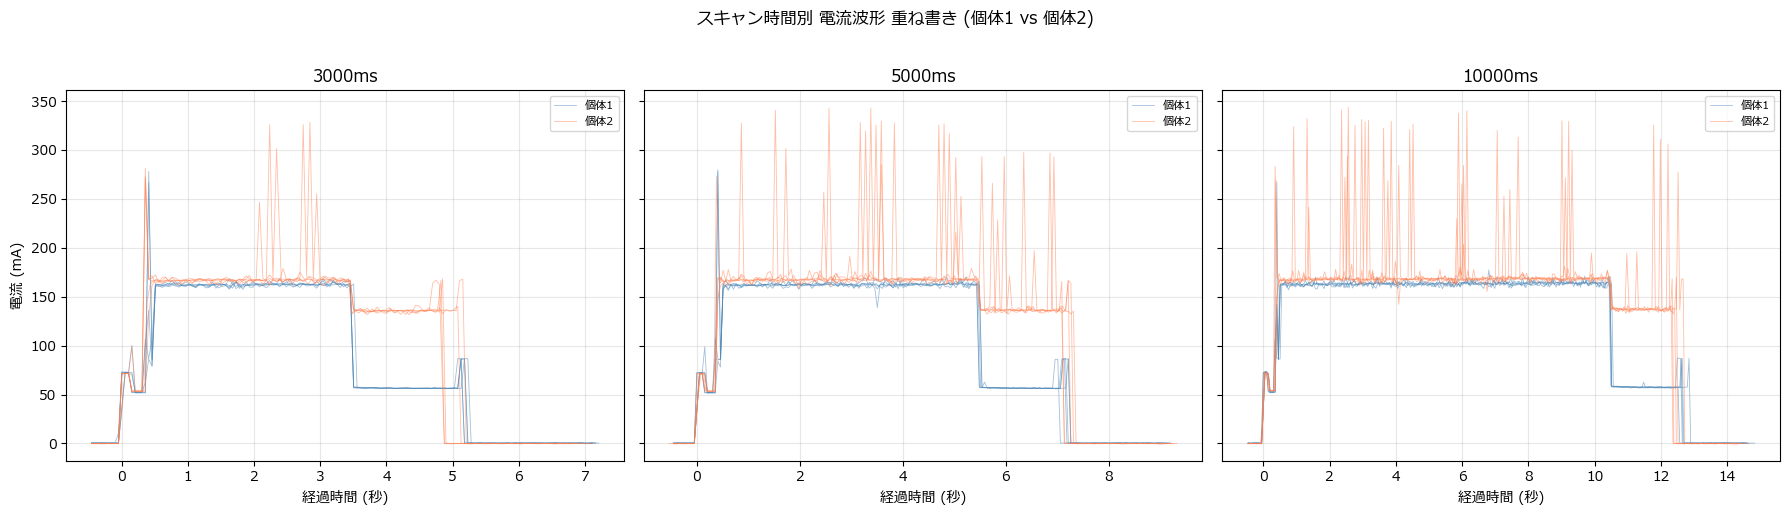

In [12]:
# ============================================================
# スキャン時間別 各サイクル重ね書き (2個体、立ち上がり/立ち下がり含む)
# ============================================================
MARGIN_BEFORE = 0.5  # ON区間の前 (秒)
MARGIN_AFTER = 2.0   # ON区間の後 (秒)

fig, axes = plt.subplots(1, len(SCAN_PATTERNS_MS), figsize=(18, 5), sharey=True)

colors = {'個体1': 'steelblue', '個体2': 'coral'}

for pidx, scan_ms in enumerate(SCAN_PATTERNS_MS):
    ax = axes[pidx]
    
    for label, data in results_all.items():
        df_plot = data['df']
        valid = data['valid']
        current = df_plot['Current (mA)'].values
        timestamps = df_plot['elapsed_s'].values
        dt = np.median(np.diff(timestamps))
        
        start_i = pidx * REPS_PER_PATTERN
        end_i = start_i + REPS_PER_PATTERN
        subset = valid[start_i:end_i]
        
        for r, (s, e) in enumerate(subset):
            # マージン分のインデックスを追加
            margin_before_samples = int(MARGIN_BEFORE / dt)
            margin_after_samples = int(MARGIN_AFTER / dt)
            s_ext = max(0, s - margin_before_samples)
            e_ext = min(len(timestamps), e + margin_after_samples)
            
            t = timestamps[s_ext:e_ext] - timestamps[s]  # ON区間開始を0に
            c = current[s_ext:e_ext]
            lbl = label if r == 0 else None
            ax.plot(t, c, linewidth=0.6, alpha=0.5, color=colors[label], label=lbl)
    
    ax.set_title(f'{scan_ms}ms')
    ax.set_xlabel('経過時間 (秒)')
    if pidx == 0:
        ax.set_ylabel('電流 (mA)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle('スキャン時間別 電流波形 重ね書き (個体1 vs 個体2)', y=1.02)
plt.tight_layout()
plt.show()